# GenLLM

### Installing Libraries

In [ ]:
!pip install -q \
    trl==0.11.1 \
    transformers==4.45.2 \
    datasets==3.0.1 \
    peft==0.13.2 \
    accelerate==1.0.1 \
    evaluate==0.4.3 \
    scikit-learn \
    pandas \
    numpy \
    torchmetrics

## Importing Libraries

In [1]:
import torch
from torch.utils.data import Dataset
from tqdm import tqdm
import evaluate
from datasets import load_dataset
from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import LoraConfig, TaskType, get_peft_model
from trl import SFTConfig, SFTTrainer, DataCollatorForCompletionOnlyLM

import matplotlib.pyplot as plt

In [3]:
device = 'cuda'

## 1. Dataset Preparation

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
dataset_path = "/content/drive/MyDrive/MIRA/Datasets/mira_genllm_sft_10000.jsonl"

In [5]:
dataset = load_dataset('json', data_files = dataset_path)
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['messages', 'metadata'],
        num_rows: 10000
    })
})


In [6]:
dataset = dataset.shuffle(seed = 42)

In [7]:
dataset['train'][5]

{'messages': [{'role': 'system',
   'content': 'You are MIRA, an AI-based coal mine inspection and compliance assistant. Use the supplied inspection evidence and Retrieved Guidance. Do not calculate risk, alter classification fields, invent inspection history, or invent regulatory requirements. Respond in clear professional English.'},
  {'role': 'user',
   'content': 'Language: English\n\nUser Query: Explain why F-01 requires attention.\n\nInspection ID: INS-2026-1912\nMine: Suryodaya Colliery\n\nFinding ID: F-01\nFinding Text: During the inspection, the condition was observed while the area was under routine operational activity. The affected condition was noted around surface-water diversion at the southern production bench. The measured sump freeboard was 0.42 m, compared with a reference value of 0.75 m indicated in the supplied inspection context. Management records supplied with the inspection indicate that the earlier recommendation remains pending. The finding should be addres

### Train-Test Split

In [8]:
dataset_split = dataset['train'].train_test_split(test_size = 0.05, seed = 42)
train_dataset = dataset_split['train']
test_dataset = dataset_split['test']

dataset_split

DatasetDict({
    train: Dataset({
        features: ['messages', 'metadata'],
        num_rows: 9500
    })
    test: Dataset({
        features: ['messages', 'metadata'],
        num_rows: 500
    })
})

In [23]:
def format_chat(example):
    return {
        "text": tokenizer.apply_chat_template(
            example["messages"],
            tokenize=False,
            add_generation_prompt=False
        )
    }

train_dataset = train_dataset.map(format_chat)
test_dataset = test_dataset.map(format_chat)

Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

## Model

In [9]:
model_name = 'Qwen/Qwen2.5-3B-Instruct'

In [10]:
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype=torch.float16,
)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

In [11]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

### Perform Fine-Tuning with LoRA

In [13]:
lora_config = LoraConfig(
    task_type = TaskType.CAUSAL_LM,
    r = 16,
    lora_alpha = 32,
    lora_dropout = 0.05,
    target_modules = [
        'q_proj',
        'k_proj',
        'v_proj',
        'o_proj',
        'gate_proj',
        'up_proj',
        'down_proj'
    ],
    bias = "none"
)

### Wrapping Model with LoRA

In [14]:
model = get_peft_model(model, lora_config)

In [15]:
model.print_trainable_parameters()

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


## SFT Config

In [30]:
from trl import SFTConfig

sft_config = SFTConfig(
    output_dir = "/content/drive/MyDrive/MIRA/MIRA2_checkpoints/",

    num_train_epochs = 2,

    per_device_train_batch_size = 1,
    per_device_eval_batch_size = 1,

    gradient_accumulation_steps = 8,

    learning_rate = 2e-4,

    fp16 = True,
    bf16 = False,

    logging_steps = 10,
    eval_steps = 100,
    save_steps = 100,

    evaluation_strategy = 'steps',
    save_strategy = 'steps',

    max_seq_length = 512,

    report_to = "none",

    load_best_model_at_end = False,

    seed = 42
)

/usr/local/lib/python3.13/dist-packages/transformers/training_args.py:1545: FutureWarning: `evaluation_strategy` is deprecated and will be removed in version 4.46 of 🤗 Transformers. Use `eval_strategy` instead
  warnings.warn(


### SFT Trainer

In [31]:
trainer = SFTTrainer(
    model = model,
    train_dataset = train_dataset,
    eval_dataset = test_dataset,
    tokenizer = tokenizer,
    dataset_text_field = 'text',
    args = sft_config,
)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field. Will not be supported from version '1.0.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/usr/local/lib/python3.13/dist-packages/trl/trainer/sft_trainer.py:321: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(


Map:   0%|          | 0/9500 [00:00<?, ? examples/s]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

### Resuming training from checkpoint-1500

In [29]:
from peft import PeftModel

checkpoint_path = "/content/drive/MyDrive/MIRA/MIRA2_checkpoints/checkpoint-1500"

model = PeftModel.from_pretrained(
    model,
    checkpoint_path,
    is_trainable=True
)

model.print_trainable_parameters()

trainable params: 29,933,568 || all params: 3,115,872,256 || trainable%: 0.9607


In [34]:
import os

checkpoint_path = "/content/drive/MyDrive/MIRA/MIRA2_checkpoints/checkpoint-1500"

rng_file = os.path.join(checkpoint_path, "rng_state.pth")

# Backup the RNG state file
os.rename(
    rng_file,
    rng_file + ".bak"
)

print("RNG state temporarily disabled.")

RNG state temporarily disabled.


In [35]:
trainer.train(
    resume_from_checkpoint=checkpoint_path
)

Step,Training Loss,Validation Loss
1600,0.078300,0.074337
1700,0.059400,0.056026
1800,0.052300,0.051072
1900,0.047700,0.049151
2000,0.047600,0.047187
2100,0.046600,0.046716
2200,0.044900,0.044928
2300,0.042600,0.043503


TrainOutput(global_step=2374, training_loss=0.034267979397076764, metrics={'train_runtime': 4714.3573, 'train_samples_per_second': 4.03, 'train_steps_per_second': 0.504, 'total_flos': 1.4561265786812006e+17, 'train_loss': 0.034267979397076764, 'epoch': 1.9995789473684211})

In [36]:
log_history_lora = trainer.state.log_history

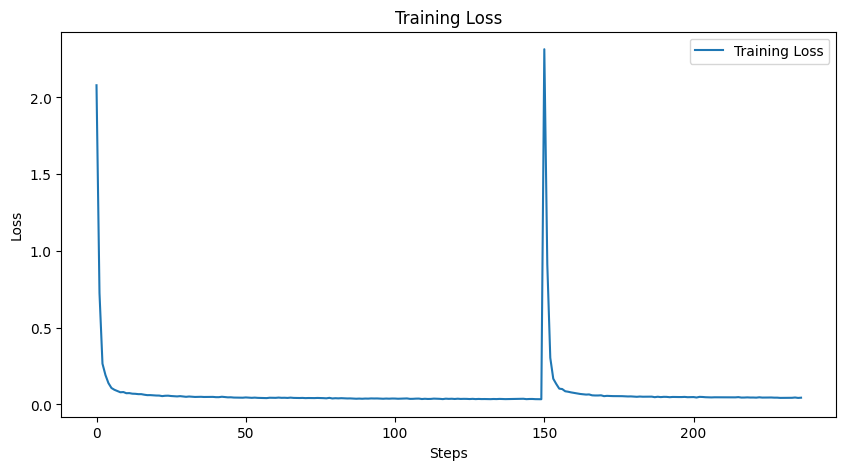

In [37]:
train_loss = [log['loss'] for log in log_history_lora if 'loss' in log]

plt.figure(figsize = (10, 5))
plt.plot(train_loss, label = 'Training Loss')

plt.xlabel('Steps')
plt.ylabel('Loss')
plt.title('Training Loss')
plt.legend()
plt.show()

In [38]:
trainer.save_model(
    "/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora"
)

tokenizer.save_pretrained(
    "/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora"
)

('/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/tokenizer_config.json',
 '/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/special_tokens_map.json',
 '/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/vocab.json',
 '/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/merges.txt',
 '/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/added_tokens.json',
 '/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora/tokenizer.json')

---

# Inference Section

In [ ]:
import torch
import os

from transformers import AutoModelForCausalLM, AutoTokenizer, pipeline
from peft import PeftModel


OFFLOAD_DIR = "/content/offload"
os.makedirs(OFFLOAD_DIR, exist_ok=True)

BASE_MODEL = "Qwen/Qwen2.5-3B-Instruct"
LORA_PATH = "/content/drive/MyDrive/MIRA/models/MIRA2_qwen2.5-3b-lora"

# setting up tokenizer
tokenizer = AutoTokenizer.from_pretrained(LORA_PATH)

# setting up base model
base_model = AutoModelForCausalLM.from_pretrained(
    BASE_MODEL,
    torch_dtype = torch.float16,
    offload_folder = OFFLOAD_DIR
).to('cuda')

# attaching LoRA adapter
model = PeftModel.from_pretrained(
    base_model,
    LORA_PATH
)

In [40]:
gen_pipeline = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    batch_size=2,
    truncation=True,
    padding=False,
    return_full_text=False
)

Hardware accelerator e.g. GPU is available in the environment, but no `device` argument is passed to the `Pipeline` object. Model will be on CPU.
The model 'PeftModelForCausalLM' is not supported for text-generation. Supported models are ['BartForCausalLM', 'BertLMHeadModel', 'BertGenerationDecoder', 'BigBirdForCausalLM', 'BigBirdPegasusForCausalLM', 'BioGptForCausalLM', 'BlenderbotForCausalLM', 'BlenderbotSmallForCausalLM', 'BloomForCausalLM', 'CamembertForCausalLM', 'LlamaForCausalLM', 'CodeGenForCausalLM', 'CohereForCausalLM', 'CpmAntForCausalLM', 'CTRLLMHeadModel', 'Data2VecTextForCausalLM', 'DbrxForCausalLM', 'ElectraForCausalLM', 'ErnieForCausalLM', 'FalconForCausalLM', 'FalconMambaForCausalLM', 'FuyuForCausalLM', 'GemmaForCausalLM', 'Gemma2ForCausalLM', 'GitForCausalLM', 'GPT2LMHeadModel', 'GPT2LMHeadModel', 'GPTBigCodeForCausalLM', 'GPTNeoForCausalLM', 'GPTNeoXForCausalLM', 'GPTNeoXJapaneseForCausalLM', 'GPTJForCausalLM', 'GraniteForCausalLM', 'GraniteMoeForCausalLM', 'JambaFor

In [41]:
from transformers import TextIteratorStreamer
from threading import Thread

In [45]:
def generate_response(user_prompt, max_new_tokens=300):

    model.eval()

    messages = [
        {
            "role": "system",
            "content": (
                "You are MIRA (Mine Intelligence and Risk Assessment), "
                "an AI-based coal mine inspection and compliance assistant. "

                "Use only the supplied inspection findings, structured AI "
                "assessment, risk information, and retrieved regulatory guidance "
                "to answer the user's question. "

                "Do not calculate, modify, or override the provided issue, "
                "category, severity, recurring status, risk level, or risk confidence. "

                "Do not invent regulations, rule numbers, legal provisions, "
                "inspection history, or evidence that is not present in the context. "

                "For compliance-related questions, use only the Retrieved Guidance "
                "provided in the user prompt. "

                "If Language is English, respond in clear professional English. "

                "If Language is Hindi, understand Romanized Hindi or Hinglish "
                "input and respond ONLY in standard Hindi using Devanagari script. "
                "Do not respond in Romanized Hindi or English."
            )
        },
        {
            "role": "user",
            "content": user_prompt
        }
    ]

    prompt = tokenizer.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True
    )

    inputs = tokenizer(
        prompt,
        return_tensors="pt"
    ).to(model.device)

    streamer = TextIteratorStreamer(
        tokenizer,
        skip_prompt=True,
        skip_special_tokens=True
    )

    generation_kwargs = {
        **inputs,
        "streamer": streamer,
        "max_new_tokens": max_new_tokens,
        "do_sample": False,
        "pad_token_id": tokenizer.pad_token_id,
        "eos_token_id": tokenizer.eos_token_id
    }

    thread = Thread(
        target=model.generate,
        kwargs=generation_kwargs
    )

    thread.start()

    response = ""

    for new_text in streamer:
        print(new_text, end="", flush=True)
        response += new_text

    thread.join()

    return response

In [46]:
user_prompt = """
Language: Hindi

User Query: F-01 itna serious kyun hai?

Finding ID: F-01

Finding:
Eastern working panel mein ventilation inadequate paya gaya. Airflow 1.9 m/s tha jabki required value 2.5 m/s hai. Ventilation ducting mein visible wear aur multiple seams mile. Yeh deficiency previous inspection mein bhi record hui thi aur duct replacement ki recommendation implement nahi hui.

Issue: Ventilation
Category: Mine Safety
Severity: Critical
Recurring: Yes
Risk Level: Critical
Risk Confidence: 91.19%

Retrieved Guidance:
Supplied CMR 2017 guidance ke anusaar working areas mein adequate ventilation maintain karna aur ventilation equipment ko effective working condition mein rakhna zaroori hai.
"""

generate_response(user_prompt)

F-01 इस तरह ठीक नहीं है क्योंकि मिनिंग सुरक्षा के चालन क्षेत्र में वायु विकास की अपूर्णता पाई गई है। इसका वायु विकास 1.9 मीटर/सेकंड था, जबकि आवश्यक मानक 2.5 मीटर/सेकंड है। इसके अलावा, वायु विकास डॉक्टर में दिखाई दिए गए व्यर्थ और बहुत सारी छेदें पाई गईं। यह अपूर्णता पिछली इंसाफिंग में भी रिकॉर्ड हुई थी और डॉक्टर क

'F-01 इस तरह ठीक नहीं है क्योंकि मिनिंग सुरक्षा के चालन क्षेत्र में वायु विकास की अपूर्णता पाई गई है। इसका वायु विकास 1.9 मीटर/सेकंड था, जबकि आवश्यक मानक 2.5 मीटर/सेकंड है। इसके अलावा, वायु विकास डॉक्टर में दिखाई दिए गए व्यर्थ और बहुत सारी छेदें पाई गईं। यह अपूर्णता पिछली इंसाफिंग में भी रिकॉर्ड हुई थी और डॉक्टर क'